In [3]:
import pandas as pd
import os

# Define the dataset path using your absolute file path
dataset_path = "spotify_top_1000_tracks.csv"

# Load dataset
df = pd.read_csv(dataset_path, encoding="utf-8")

# Convert release_date and extract year
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

# FIX: We REMOVE the line that tried to create 'duration_min'
# because it already exists in the CSV file you loaded.
# (The 'duration_min' column is ready for use!)

print(" Dataset loaded and basic preprocessing complete!")
print(df.head(3))

 Dataset loaded and basic preprocessing complete!
                 track_name          artist  \
0  All The Stars (with SZA)  Kendrick Lamar   
1                   Starboy      The Weeknd   
2                  Señorita    Shawn Mendes   

                                               album release_date  popularity  \
0  Black Panther The Album Music From And Inspire...   2018-02-09          95   
1                                            Starboy   2016-11-25          90   
2                                           Señorita   2019-06-21          80   

                                         spotify_url                      id  \
0  https://open.spotify.com/track/3GCdLUSnKSMJhs4...  3GCdLUSnKSMJhs4Tj6CV3s   
1  https://open.spotify.com/track/7MXVkk9YMctZqd1...  7MXVkk9YMctZqd1Srtv4MB   
2  https://open.spotify.com/track/0TK2YIli7K1leLo...  0TK2YIli7K1leLovkQiNik   

   duration_min    year  
0      3.869767  2018.0  
1      3.840883  2016.0  
2      3.182667  2019.0  


In [4]:
import numpy as np

# Clean up text columns
df['track_name'] = df['track_name'].str.strip()
df['artist'] = df['artist'].str.strip()
df['album'] = df['album'].str.strip()

# Convert 'year' to integer
df['year'] = df['year'].fillna(0).astype(int)

# Drop unnecessary columns
cols_to_drop = ['spotify_url', 'id', 'release_date']

# Check for and add other common audio feature columns if they exist
if 'time_signature' in df.columns:
    cols_to_drop.append('time_signature')
if 'key' in df.columns:
    cols_to_drop.append('key')
if 'mode' in df.columns:
    cols_to_drop.append('mode')

df = df.drop(columns=cols_to_drop, errors='ignore')

# Feature Engineering: Tempo Category
tempo_bins = [0, 100, 140, np.inf]
tempo_labels = ['Slow', 'Medium', 'Fast']

if 'tempo' in df.columns:
    df['tempo_category'] = pd.cut( # Create tempo category column
        df['tempo'], bins=tempo_bins,
        labels=tempo_labels, right=False
    )
    print("Feature 'tempo_category' created.")
else:
    print("Warning: 'tempo' column not found; skipping 'tempo_category' creation.")

# Remove duplicates
df = df.drop_duplicates(subset=['track_name', 'artist'], keep='first')
print(f" Data cleaning and feature engineering complete.")
print(f"Final Row Count after deduplication: {len(df)}")

 Data cleaning and feature engineering complete.
Final Row Count after deduplication: 971


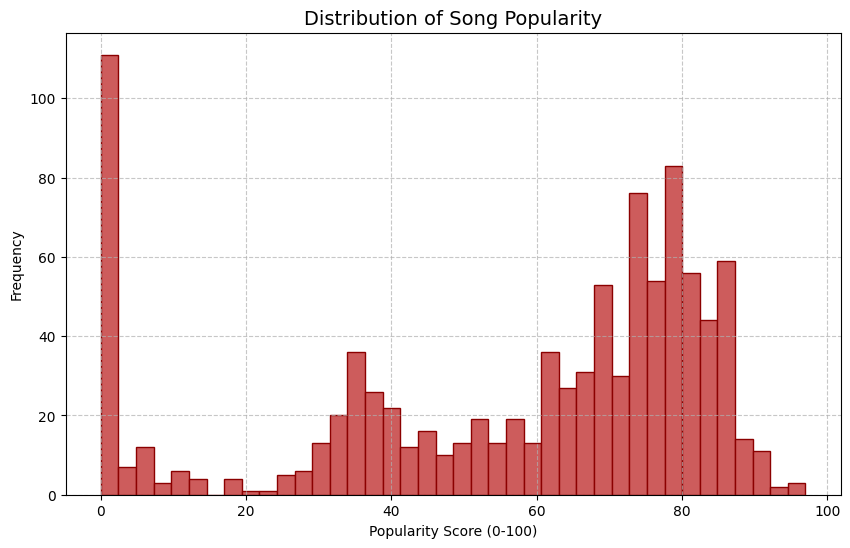

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['popularity'], bins=40, color='indianred',
edgecolor='darkred')
plt.title('Distribution of Song Popularity', fontsize=14)
plt.xlabel('Popularity Score (0-100)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

/var/folders/m7/wk2q3jkx7_3gdqgnqhvc7z5r0000gp/T/ipykernel_11012/1229301356.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data=df, palette='viridis')


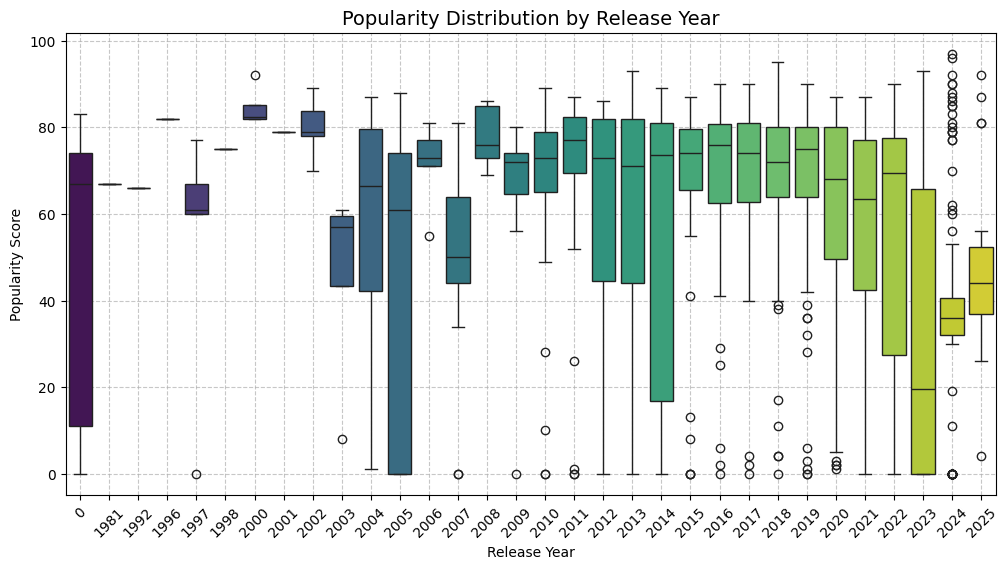

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='popularity', data=df, palette='viridis')
plt.title('Popularity Distribution by Release Year', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Popularity Score')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

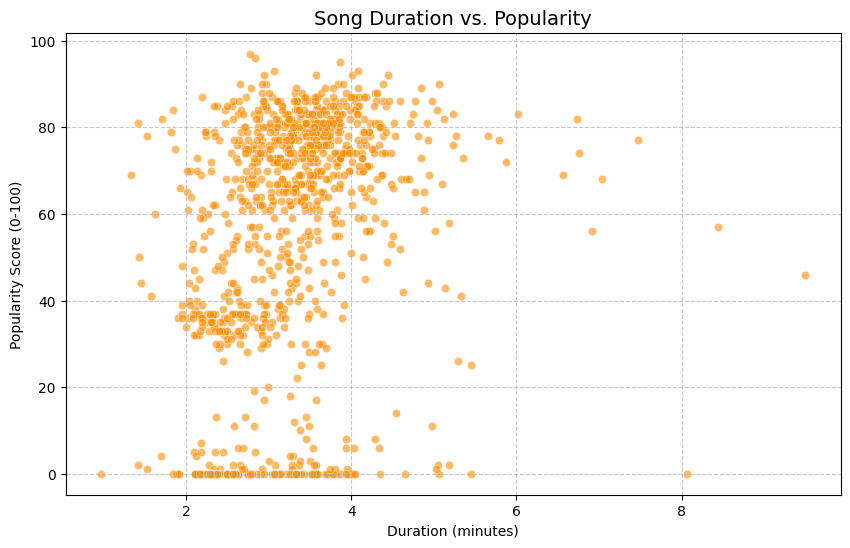

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_min', y='popularity', data=df, alpha=0.6,
color='darkorange')
plt.title('Song Duration vs. Popularity', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity Score (0-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

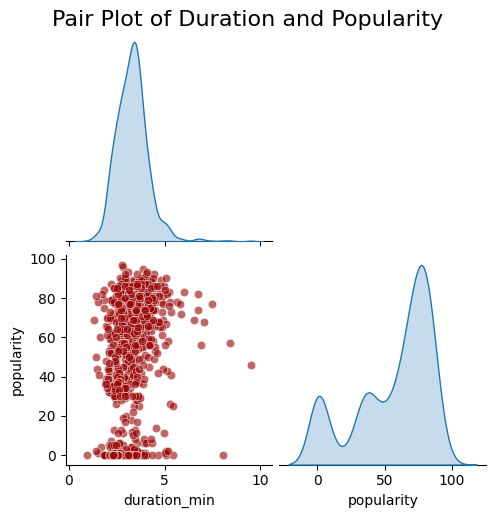

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Using only the confirmed numerical columns: 'duration_min' and 'popularity'
key_features = ['duration_min', 'popularity']

# We use the simplified sns.pairplot function
sns.pairplot(
    df[key_features],
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.6, 'color': '#990000'}
)
plt.suptitle('Pair Plot of Duration and Popularity', y=1.02, fontsize=16)
plt.show()

<Figure size 800x800 with 0 Axes>

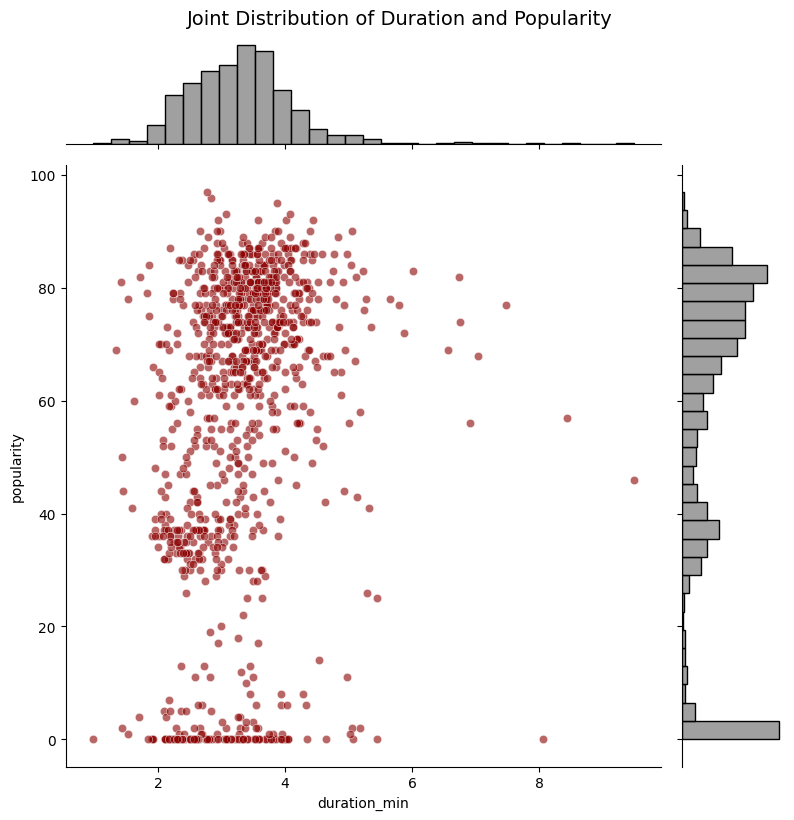

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))
sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='scatter', # Use 'scatter' for the central plot type
    height=8,       # Controls the overall size of the plot
    marginal_kws={'bins': 30, 'color': 'gray', 'edgecolor': 'black'},
    joint_kws={'alpha': 0.6, 'color': 'darkred'}
)
plt.suptitle('Joint Distribution of Duration and Popularity', y=1.02, fontsize=14)
plt.show()

In [10]:
# Requirements:
# pip install matplotlib pillow pandas
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import webbrowser

# --- Step 1: Load Dataset ---
csv_files = "spotify_top_1000_tracks.csv"
df = pd.read_csv(csv_files)

# --- Step 2: Data Preparation ---
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
df = df.dropna(subset=['year'])

# Compute average popularity per year
yearly_popularity = df.groupby('year')['popularity'].mean().reset_index()
yearly_popularity = yearly_popularity.sort_values('year')

# --- Step 3: Initialize the Figure ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(yearly_popularity['year'].min(), yearly_popularity['year'].max())
ax.set_ylim(0, yearly_popularity['popularity'].max() * 1.1)

# Fixed syntax error: brought 'label' onto one line
line, = ax.plot([], [], color='royalblue', linewidth=2.5, label='Average Popularity')

ax.set_title("Evolution of Track Popularity Over Time", fontsize=14, color='navy')
ax.set_xlabel("Year of Release", fontsize=12)
ax.set_ylabel("Average Popularity", fontsize=12)
ax.legend(loc="upper left")
plt.tight_layout()

# --- Step 4: Define Animation Function ---
def animate(i):
    x = yearly_popularity['year'][:i]
    y = yearly_popularity['popularity'][:i]
    line.set_data(x, y)
    return line,

# --- Step 5: Create and Save Animation ---
ani = FuncAnimation(fig, animate, frames=len(yearly_popularity), interval=100, repeat=False)

# Automatically Save the GIF
gif_path = os.path.abspath("yearly_popularity_trend.gif")
ani.save(gif_path, writer=PillowWriter(fps=10))
print(f" GIF saved successfully at: {gif_path}")

# --- Step 6: Open the Saved GIF ---
webbrowser.open(f"file://{gif_path}") # Opens the saved GIF automatically
plt.close(fig)

 GIF saved successfully at: /Users/johncarlmisalang/ComProg_Lab/Lab7_DataVisualization_Misalang/yearly_popularity_trend.gif


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

student_name = "John Carl Misalang"
student_id = "20250478" # Replace with your actual ID

id_num = int(student_id[-3:])
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"

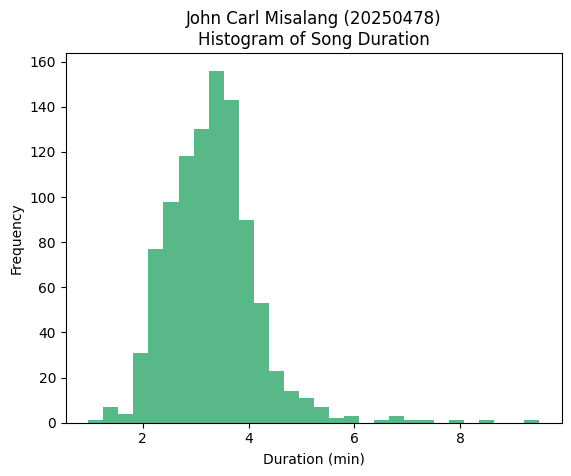

In [12]:
df['duration_min'].plot(kind='hist', bins=30, color=color1, alpha=0.7)
plt.title(f"{student_name} ({student_id})\nHistogram of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Frequency')
plt.show()

/var/folders/m7/wk2q3jkx7_3gdqgnqhvc7z5r0000gp/T/ipykernel_11012/2022922137.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')


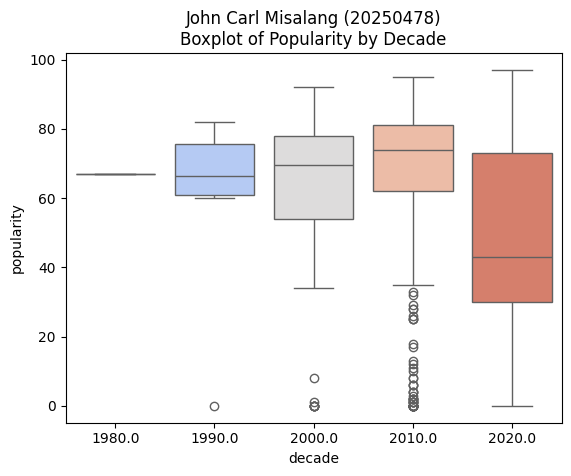

In [13]:
df['decade'] = (df['year'] // 10) * 10
sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')
plt.title(f"{student_name} ({student_id})\nBoxplot of Popularity by Decade")
plt.show()

/var/folders/m7/wk2q3jkx7_3gdqgnqhvc7z5r0000gp/T/ipykernel_11012/2607157399.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='artist', data=df,


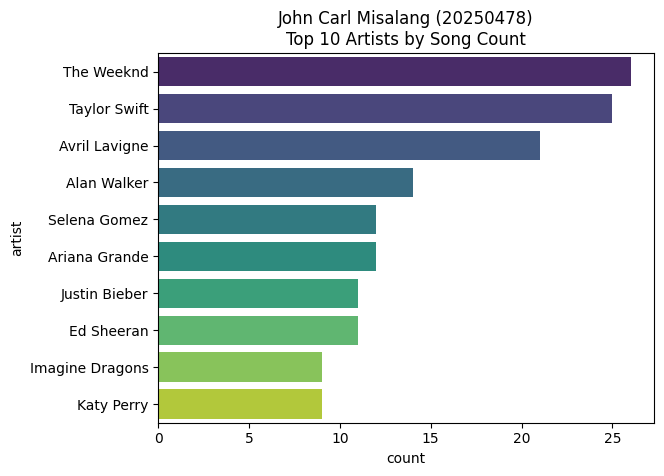

In [14]:
sns.countplot(y='artist', data=df,
order=df['artist'].value_counts().head(10).index, palette='viridis')
plt.title(f"{student_name} ({student_id})\nTop 10 Artists by Song Count")
plt.show()

/var/folders/m7/wk2q3jkx7_3gdqgnqhvc7z5r0000gp/T/ipykernel_11012/3035391425.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm',
/var/folders/m7/wk2q3jkx7_3gdqgnqhvc7z5r0000gp/T/ipykernel_11012/3035391425.py:1: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm',


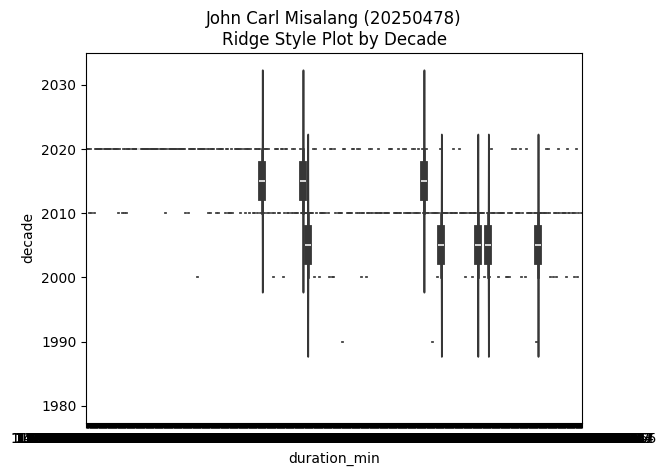

In [15]:
sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm',
scale='width')
plt.title(f"{student_name} ({student_id})\nRidge Style Plot by Decade")
plt.show()

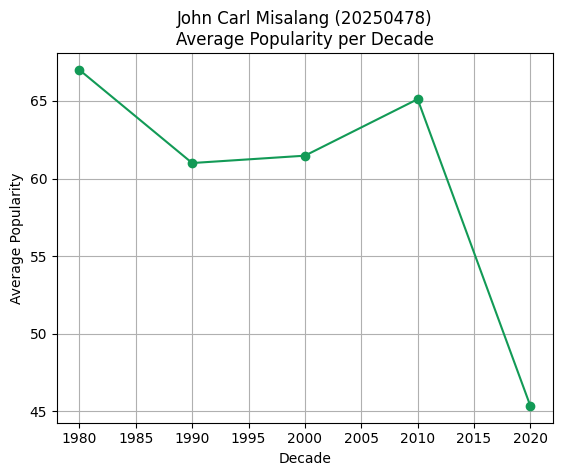

In [16]:
avg_pop = df.groupby('decade')['popularity'].mean()
avg_pop.plot(kind='line', color=color1, marker='o')
plt.title(f"{student_name} ({student_id})\nAverage Popularity per Decade")
plt.xlabel('Decade')
plt.ylabel('Average Popularity')
plt.grid(True)
plt.show()

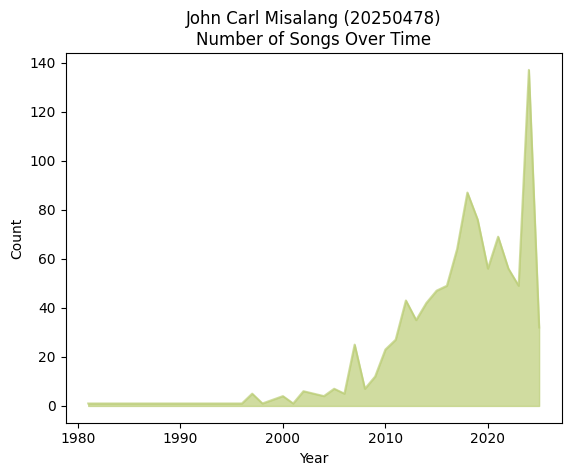

In [17]:
df['release_year'] = pd.to_datetime(df['release_date'],
errors='coerce').dt.year
count_by_year = df['release_year'].value_counts().sort_index()
count_by_year.plot(kind='area', color=color2, alpha=0.7)
plt.title(f"{student_name} ({student_id})\nNumber of Songs Over Time")
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

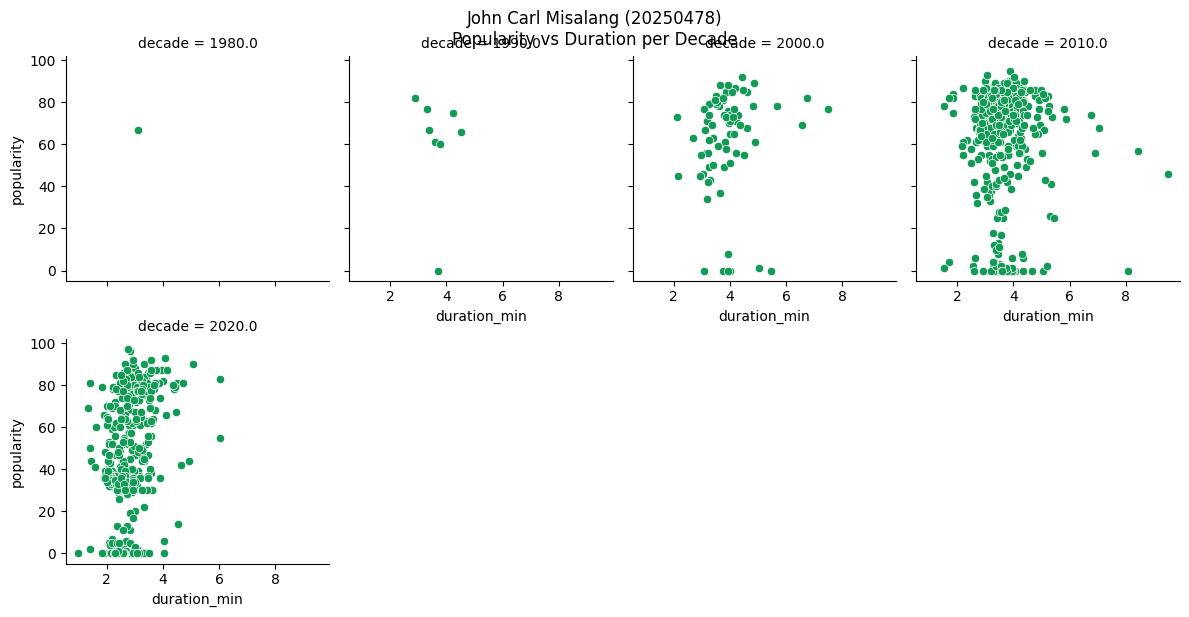

In [18]:
g = sns.FacetGrid(df, col='decade', col_wrap=4, height=3)
g.map_dataframe(sns.scatterplot, x='duration_min', y='popularity', color=color1)
g.fig.suptitle(f"{student_name} ({student_id})\nPopularity vs Duration per Decade", y=1.02)
plt.show()

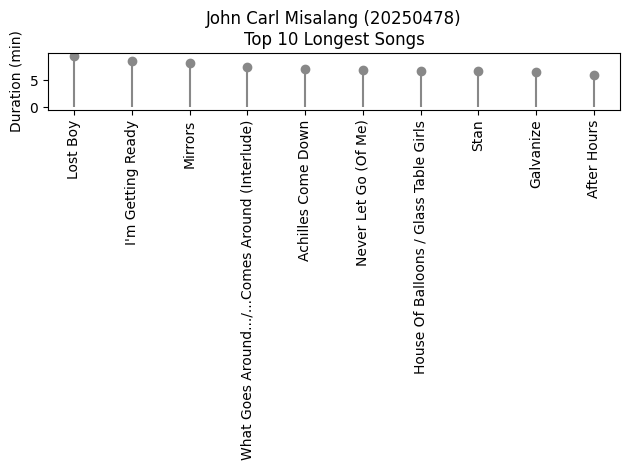

In [19]:
longest = df.nlargest(10, 'duration_min')
plt.stem(longest['track_name'], longest['duration_min'],
linefmt='#888888', markerfmt='o', basefmt=" ")
plt.xticks(rotation=90)
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs")
plt.ylabel('Duration (min)')
plt.tight_layout()
plt.show()

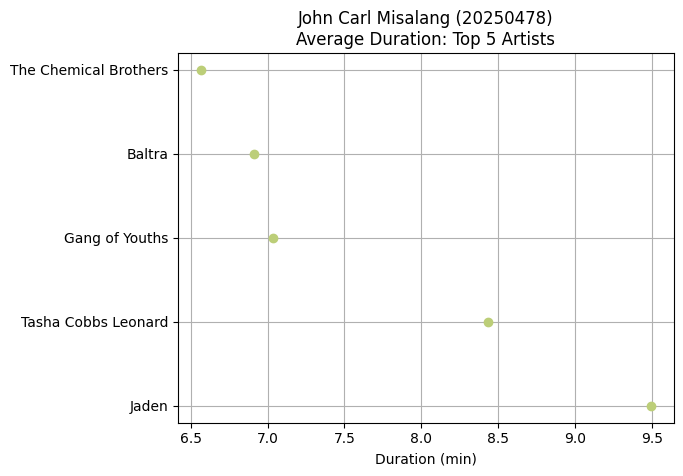

In [20]:
avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5)
plt.plot(avg_duration.values, avg_duration.index, 'o', color=color2)
plt.title(f"{student_name} ({student_id})\nAverage Duration: Top 5 Artists")
plt.xlabel('Duration (min)')
plt.grid(True)
plt.show()

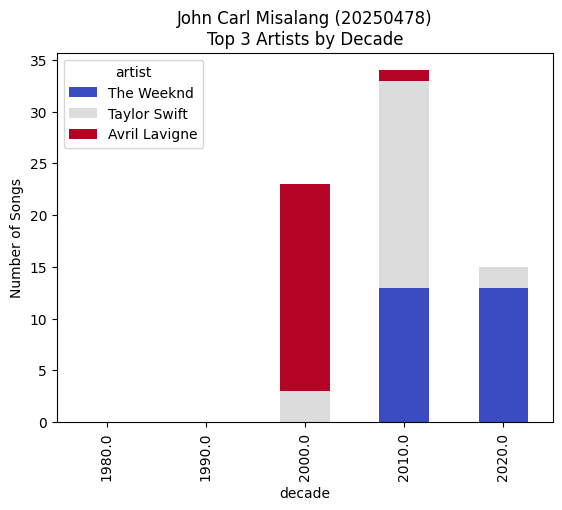

In [21]:
crosstab = pd.crosstab(df['decade'], df['artist'])
top3 = df['artist'].value_counts().head(3).index
crosstab[top3].plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title(f"{student_name} ({student_id})\nTop 3 Artists by Decade")
plt.ylabel('Number of Songs')
plt.show()

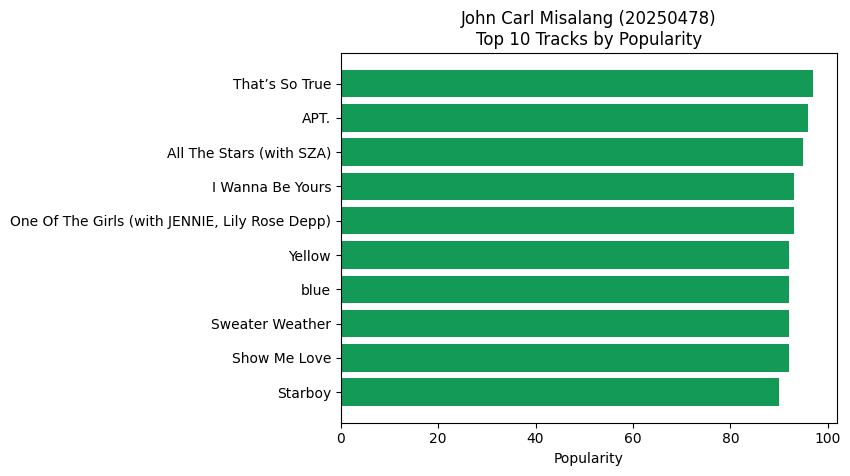

In [22]:
top_tracks = df.nlargest(10, 'popularity')
plt.barh(top_tracks['track_name'], top_tracks['popularity'], color=color1)
plt.xlabel('Popularity')
plt.title(f"{student_name} ({student_id})\nTop 10 Tracks by Popularity")
plt.gca().invert_yaxis()
plt.show()

/var/folders/m7/wk2q3jkx7_3gdqgnqhvc7z5r0000gp/T/ipykernel_11012/1836170382.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',
/var/folders/m7/wk2q3jkx7_3gdqgnqhvc7z5r0000gp/T/ipykernel_11012/1836170382.py:2: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',


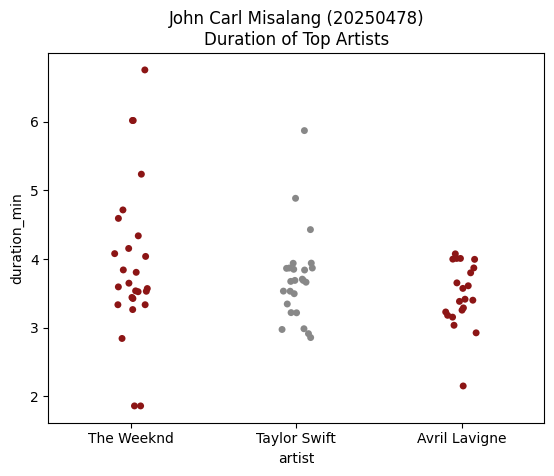

In [23]:
top_artists = df['artist'].value_counts().head(3).index
sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',
y='duration_min', palette=['#8C1515', '#888888'])
plt.title(f"{student_name} ({student_id})\nDuration of Top Artists")
plt.show()

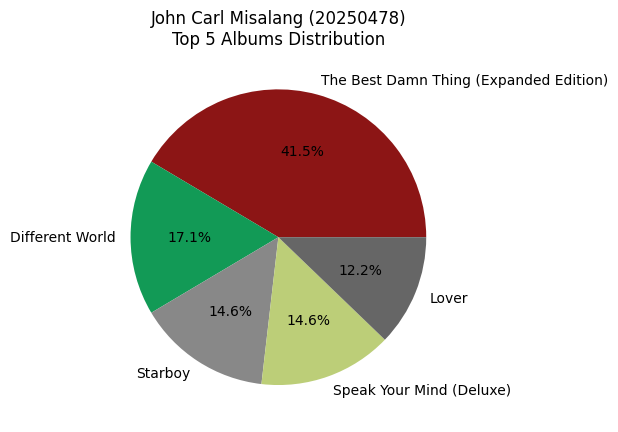

In [24]:
top_albums = df['album'].value_counts().head(5)
colors = ['#8C1515', color1, '#888888', color2, '#666666']
plt.pie(top_albums, labels=top_albums.index, autopct='%1.1f%%',
colors=colors)
plt.title(f"{student_name} ({student_id})\nTop 5 Albums Distribution")
plt.show()

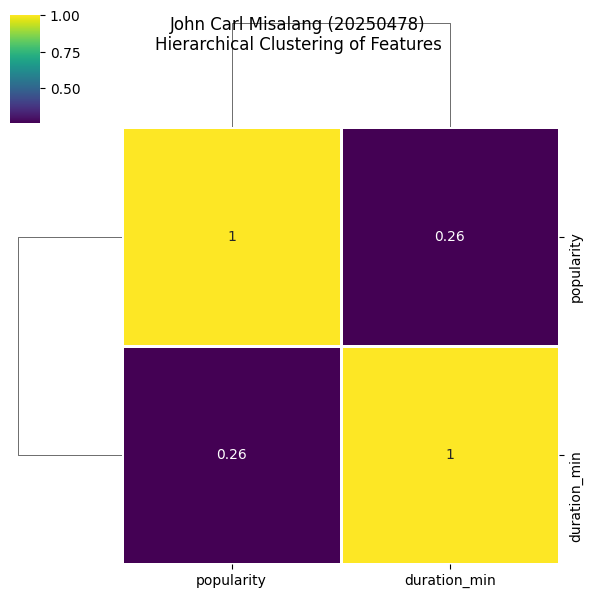

In [25]:
numerical_cols = ['popularity', 'duration_min']
df_numeric = df[numerical_cols].dropna()
sns.clustermap(df_numeric.corr(), annot=True, cmap='viridis',
linewidths=.75, figsize=(6, 6))
plt.suptitle(f"{student_name} ({student_id})\nHierarchical Clustering of Features")
plt.show()

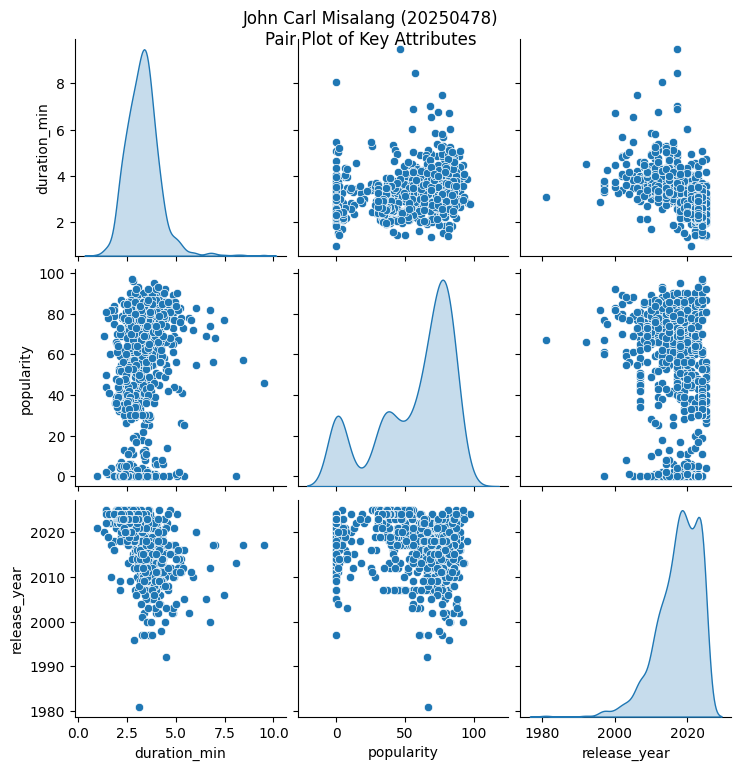

In [27]:
sns.pairplot(df[['duration_min', 'popularity', 'release_year']],
diag_kind='kde')
plt.suptitle(f"{student_name} ({student_id})\nPair Plot of Key Attributes", y=1.02)
plt.show()

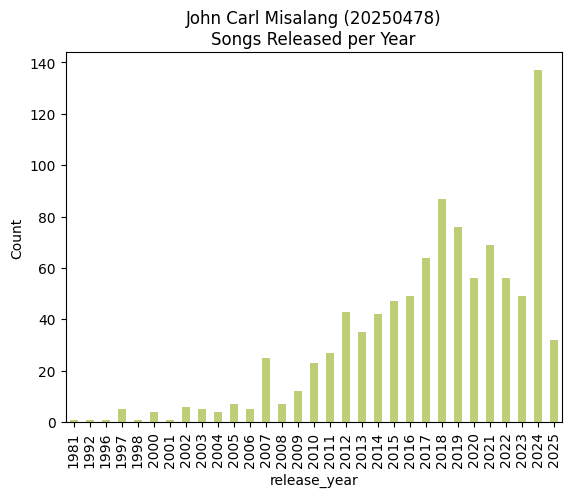

In [28]:
df['release_year'].value_counts().sort_index().plot(kind='bar',
color=color2)
plt.title(f"{student_name} ({student_id})\nSongs Released per Year")
plt.ylabel('Count')
plt.show()

/var/folders/m7/wk2q3jkx7_3gdqgnqhvc7z5r0000gp/T/ipykernel_11012/782068081.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df.head(50), x='artist', y='popularity',


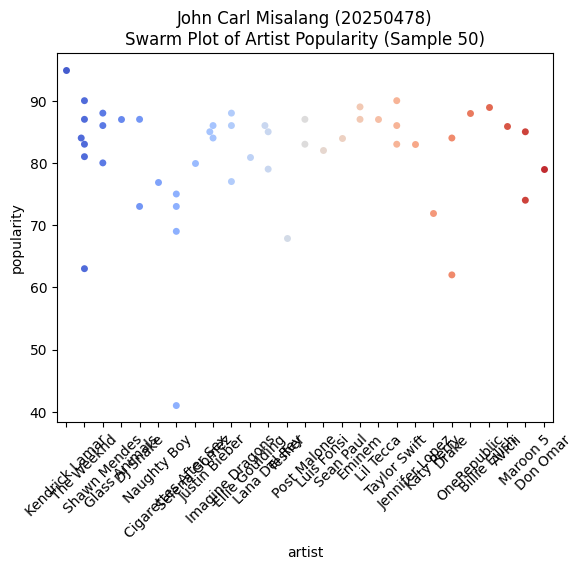

In [30]:
sns.swarmplot(data=df.head(50), x='artist', y='popularity',
palette='coolwarm')
plt.title(f"{student_name} ({student_id})\nSwarm Plot of Artist Popularity (Sample 50)")
plt.xticks(rotation=45)
plt.show()

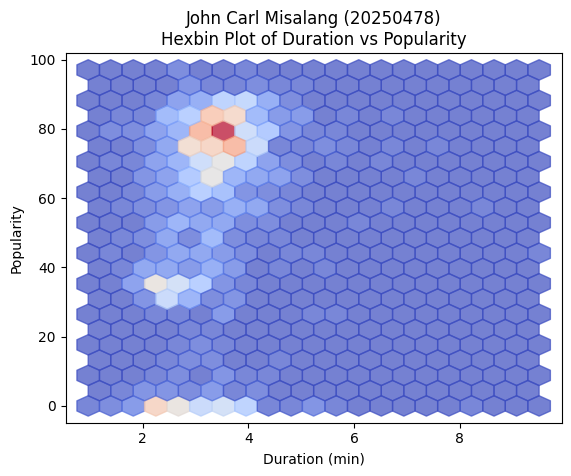

In [31]:
plt.hexbin(df['duration_min'], df['popularity'], gridsize=20,
cmap='coolwarm', alpha=0.7)
plt.xlabel('Duration (min)')
plt.ylabel('Popularity')
plt.title(f"{student_name} ({student_id})\nHexbin Plot of Duration vs Popularity")
plt.show()

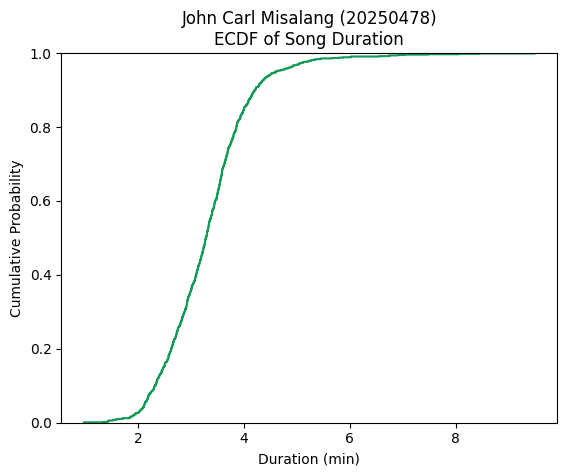

In [32]:
sns.ecdfplot(data=df, x='duration_min', color=color1)
plt.title(f"{student_name} ({student_id})\nECDF of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Cumulative Probability')
plt.show()

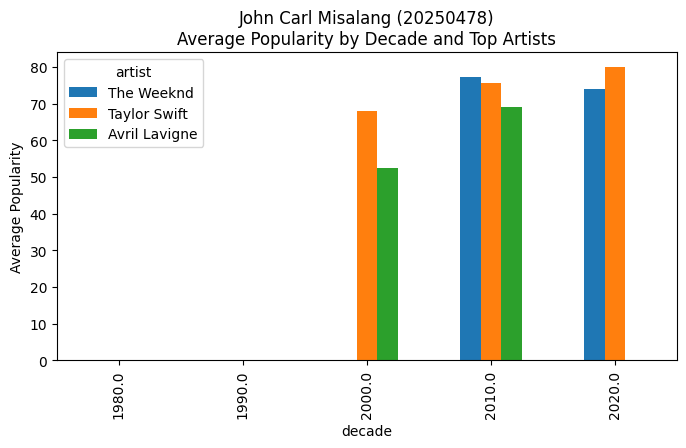

In [33]:
avg_artist_decade = df.groupby(['decade',
'artist'])['popularity'].mean().unstack().fillna(0)
avg_artist_decade[top3].plot(kind='bar', figsize=(8, 4))
plt.title(f"{student_name} ({student_id})\nAverage Popularity by Decade and Top Artists")
plt.ylabel('Average Popularity')
plt.show()